In [1]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(gridExtra)
quiet_library(grid)
quiet_library(ComplexHeatmap)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [2]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [3]:
stims <- c("IFNa", "IFNb", "IFN-L1", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [4]:
# read-in L1 DEGs
l1_degs <- map_dfr(stims, function(s){
                map_dfr(celltypes, function(c){
                   fread(file.path(wd, "DEGs", "MAST_N1_downsample", "L1_Final", 
                                            glue("Consensus_{s}_{c}_DEGs_MAST.csv"))) %>% 
                        filter(Significant == "Yes")
                            
        })
    })

In [5]:
# read in L2 DEGs
l2_degs <- map_dfr(stims, function(s){
                map_dfr(subtypes, function(c){
                   fread(file.path(wd, "DEGs", "MAST_N1_downsample", "L2_Final", 
                                            glue("Consensus_{s}_{c}_DEGs_MAST.csv"))) #%>% 
                        #filter(Significant == "Yes")
                            
        })
    })
l2_degs$stim <- factor(l2_degs$stim, levels = stims)
l2_degs$celltype <- factor(l2_degs$celltype, levels = subtypes)

### 1B. Total Cell Type and Stim UMAP

In [4]:
# clustered object with all cells and subsetted variable genes
so <- readRDS(file.path(wd, "seurat_objects", "so_complete2.rds"))

In [17]:
genes <- c("SAMD9", "SAMD9L")

In [6]:
celltypes <- c("B Naive", "CD14 Mono","CD4 Naive","CD4 TCM","CD8 Naive","CD8 TEM","NK")

In [ ]:
sub <- so %>% subset()

In [11]:
so$Subtype <- recode(so$Subtype, 
                    "Monocyte" = "CD14 Mono",
                    "NK CD56dim" = "NK",
                    "NK CD56hi" = "NK",
                     "CD4 Memory" = "CD4 TCM",
                     "CD8 Memory" = "CD8 TEM",
                     "Naive" = "B Naive"
                     
                    )

In [30]:
sub <- so %>% subset(Subtype %in% celltypes)

In [39]:
sub$Celltype_Stim %>% unique

[1] "CD14 Mono_Unstim" "CD14 Mono_IFNa"   "CD14 Mono_IFNb"   "CD14 Mono_IFNg"  
 [5] "CD14 Mono_IFN-L1" "B Naive_Unstim"   "B Naive_IFNa"     "B Naive_IFNb"    
 [9] "B Naive_IFNg"     "B Naive_IFN-L1"   "CD4 Naive_Unstim" "CD4 TCM_Unstim"  
[13] "CD8 Naive_Unstim" "CD8 TEM_Unstim"   "CD4 Naive_IFNa"   "CD4 TCM_IFNa"    
[17] "CD8 Naive_IFNa"   "CD8 TEM_IFNa"     "CD8 Naive_IFNb"   "CD4 Naive_IFNb"  
[21] "CD8 TEM_IFNb"     "CD4 TCM_IFNb"     "CD4 Naive_IFNg"   "CD8 TEM_IFNg"    
[25] "CD4 TCM_IFNg"     "CD8 Naive_IFNg"   "CD4 Naive_IFN-L1" "CD8 Naive_IFN-L1"
[29] "CD4 TCM_IFN-L1"   "CD8 TEM_IFN-L1"   "NK_Unstim"        "NK_IFNa"         
[33] "NK_IFNb"          "NK_IFNg"          "NK_IFN-L1"

In [ ]:
paste(c("none", stims), celltypes, stims, sep = "_")

In [40]:
paste(c("none", stims), celltypes, stims, sep = "_")

[1] "none_B Naive"   "IFNa_CD14 Mono" "IFNb_CD4 Naive" "IFN-L1_CD4 TCM"
[5] "IFNg_CD8 Naive" "none_CD8 TEM"   "IFNa_NK"

In [31]:
sub$Description <- factor(sub$Description, levels = c("none", stims))

In [32]:
sub$Description <- recode(sub$Description, 
                   "none" = "Unstim")

In [33]:
sub$Celltype_Stim <- paste(sub$Subtype, sub$Description, sep = "_")

In [42]:
combos <- expand.grid(celltypes = celltypes, stims = c("Unstim", stims))

order_stims <- paste(combos$celltypes, combos$stims, sep = "_")
order_stims

[1] "B Naive_Unstim"   "CD14 Mono_Unstim" "CD4 Naive_Unstim" "CD4 TCM_Unstim"  
 [5] "CD8 Naive_Unstim" "CD8 TEM_Unstim"   "NK_Unstim"        "B Naive_IFNa"    
 [9] "CD14 Mono_IFNa"   "CD4 Naive_IFNa"   "CD4 TCM_IFNa"     "CD8 Naive_IFNa"  
[13] "CD8 TEM_IFNa"     "NK_IFNa"          "B Naive_IFNb"     "CD14 Mono_IFNb"  
[17] "CD4 Naive_IFNb"   "CD4 TCM_IFNb"     "CD8 Naive_IFNb"   "CD8 TEM_IFNb"    
[21] "NK_IFNb"          "B Naive_IFN-L1"   "CD14 Mono_IFN-L1" "CD4 Naive_IFN-L1"
[25] "CD4 TCM_IFN-L1"   "CD8 Naive_IFN-L1" "CD8 TEM_IFN-L1"   "NK_IFN-L1"       
[29] "B Naive_IFNg"     "CD14 Mono_IFNg"   "CD4 Naive_IFNg"   "CD4 TCM_IFNg"    
[33] "CD8 Naive_IFNg"   "CD8 TEM_IFNg"     "NK_IFNg"

In [43]:
sub$Celltype_Stim <- factor(sub$Celltype_Stim, levels = order_stims)

In [44]:
sub$Description %>% table

.
Unstim   IFNa   IFNb IFN-L1   IFNg 
242679 214490 207974 185842 187396 

In [47]:
fig.size(3,15)
pdf("/home/workspace/IFN/SAMD9_SAMD9L_IFN_DotPlot.pdf", height = 3, width = 15)
DotPlot(sub, features = genes, group.by = "Celltype_Stim", cols = c("white", "red")) + coord_flip() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)) + 
    xlab("") + ylab("")
dev.off()

pdf 
  2

In [7]:
fig.size(4.5,6)
pdf(file.path(fig_dir, "Fig1", "UMAP_All_Subtype_Stim.pdf"), height = 4.5, width = 6)
p1 <- DimPlot(so, group.by = "Subtype", cols = subtype_cols, raster = F) + ggtitle("")
p1[[1]]$layers[[1]]$aes_params$alpha <- 0.3
p1
dev.off()

pdf 
  2

### 1C. Total Cell Type and Stim Density UMAP

In [8]:
# extract UMAP embedding coords
df <- data.frame(so@reductions$umap@cell.embeddings) %>% tibble::rownames_to_column("barcodes")
df <- df %>% left_join(so@meta.data[,c("barcodes", "Description")])

df$Description <- factor(df$Description, levels = c("none", "IFNa", "IFNb", "IFNg", "IFN-L1"))

Joining with `by = join_by(barcodes)`


null device 
          1

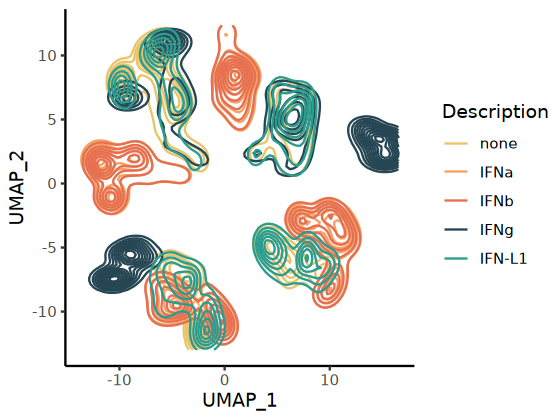

In [17]:
fig.size(3.5,4.6)
#pdf(file.path(fig_dir, "Fig1", "Density_UMAP_All_Subtype_Stim.pdf"), height = 3.3, width = 4.5)
n <- 12
gg <- ggplot(df, aes(x = UMAP_1, y = UMAP_2)) +
        geom_density_2d(bins = n, aes(color = Description))  +
        theme_classic() + 
        scale_color_manual(values=stim_cols) +  
        theme(plot.title = element_text(hjust = 0.5)) + 
        theme(plot.title = element_text(size =18)) + 
        #xlim(-15, 18) + 
        #ylim(-15, 13) + 
        scale_alpha_continuous(guide = "none") #+ theme(legend.title = element_blank())

gg
dev.off()

In [42]:
fig.size(3.5,4.6)
pdf(file.path(fig_dir, "Fig1", "Density_v2_UMAP_All_Subtype_Stim.pdf"), height = 3.3, width = 4.5)
n <- 14
gg <- ggplot(df, aes(x = UMAP_1, y = UMAP_2)) +
        stat_density_2d(geom = "polygon", bins = n, aes(alpha = ..level.., fill = Description)) + 
        theme_classic() + 
        scale_fill_manual(values=stim_cols) +  
        theme(plot.title = element_text(hjust = 0.5)) + 
        theme(plot.title = element_text(size =18)) + 
        xlim(-15, 18) + 
        ylim(-13, 13) + 
        scale_alpha_continuous(guide = "none") #+ theme(legend.title = element_blank())

gg
dev.off()

Warning message:
“Removed 2313 rows containing non-finite outside the scale range
(`stat_density2d()`).”


pdf 
  2

### 1D. Cell Type and Stim Total N1 DEGs Heatmap

In [21]:
l2_degs <- l2_degs %>% 
                    mutate(Subtype_Stim = paste(celltype, stim, sep = "_"))

In [22]:
# add missing combinations of Subtype_Stim to account for combinations without sig ISGs
subtypes <- unique(l2_degs$celltype)
stims <- unique(l2_degs$stim)

all_combinations <- expand.grid(celltype = subtypes, stim = stims)

missing_rows <- anti_join(all_combinations, l2_degs, by = c("celltype", "stim")) %>%
  mutate(Subtype_Stim = paste(celltype, stim, sep = "_"),
        median_log2FC = 0,
        median_pval = 0,
        gene = "IFI6")  

l2_degs_heatmap <- bind_rows(l2_degs, missing_rows) %>% arrange(stim, celltype)

In [23]:
# format heatmap matrix
mat <- l2_degs_heatmap %>% pivot_wider(!c(Significant, median_pval, celltype, stim),
                     names_from = Subtype_Stim, values_from = median_log2FC) %>% tibble::column_to_rownames("gene") %>%
    as.matrix()
mat[is.na(mat)] <- 0

Warning message:
“Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
ℹ Please explicitly name `id_cols`, like `id_cols = !c(Significant,
  median_pval, celltype, stim)`.”


In [24]:
HA <- ComplexHeatmap::HeatmapAnnotation(df = data.frame(Subtype = rep(subtypes, 4)), 
                                        col = list(Subtype = c("CD4 Naive" = "#03045e", 
                                                               "CD4 Memory" = "#023e8a",
                                                               "Treg" = "#0077b6", 
                                                               "CD8 Naive" = "#0096c7", 
                                                               "CD8 Memory" = "#00b4d8", 
                                                               "MAIT" = "#48cae4", 
                                                               "gdT" = "#90e0ef",
                                                               "B Naive" = "#1b4332", 
                                                             "B Memory" = "#52b788", 
                                                               "Plasma" = "#b7e4c7",
                                                               "NK.CD56hi" = "#ff9f1c", 
                                                               "NK.CD56dim" = "#ffbf69", 
                                                               "CD14 Monocyte" = "#78290f"
                  )))

In [37]:
# Annotate genes 
genes_label <- c("IFI44L", "IFI6", "ISG15",
                "TAP1", "GBP1", "GBP4")

highlight_annot <- rowAnnotation(
  Gene = anno_mark(at = which(rownames(mat) %in% genes_label), 
                   labels = genes_label, 
                   labels_gp = gpar(fontsize = 7))
)


In [47]:
fig.size(7,12)
pdf(file.path(fig_dir, "Fig1", "All_N1_DEGs_Subtype_Stim_Heatmap.pdf"), height = 8, width = 12)
col_fun <- circlize::colorRamp2(c(-4, 0, 4), c("blue", "gray95", "red"))

# Create heatmap
ComplexHeatmap::Heatmap(mat,
              name = "log2FC",
              top_annotation = HA,
              show_row_names = FALSE,
              show_column_names = T,
              column_names_side = "top",
              col = col_fun,
              column_split = factor(rep(stims, each = 13), levels = stims),
              cluster_columns = FALSE,
              cluster_column_slices = FALSE,
              clustering_distance_rows = "manhattan",
              column_title_rot = 90,
              use_raster = T) + highlight_annot
dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

### 1E. Barplot number of significant ISGs 

In [ ]:
# summarise nISGs by cell type, stim, and direction of change
l2_summary <- l2_degs %>% 
    mutate(Direction = ifelse(median_log2FC > 0, "Up", "Down")) %>% 
    group_by(stim, celltype, Direction) %>%
    summarise(nDEGs = n()) %>% 
    mutate(nDEGs = ifelse(Direction == "Down", -nDEGs, nDEGs))


In [38]:
# refactor to ensure order matches heatmap above
l2_summary$stim <- factor(l2_summary$stim, levels = stims)
l2_summary$celltype <- factor(l2_summary$celltype, levels = subtypes)
l2_summary$Direction <- factor(l2_summary$Direction, levels = c("Down", "Up"))

null device 
          1

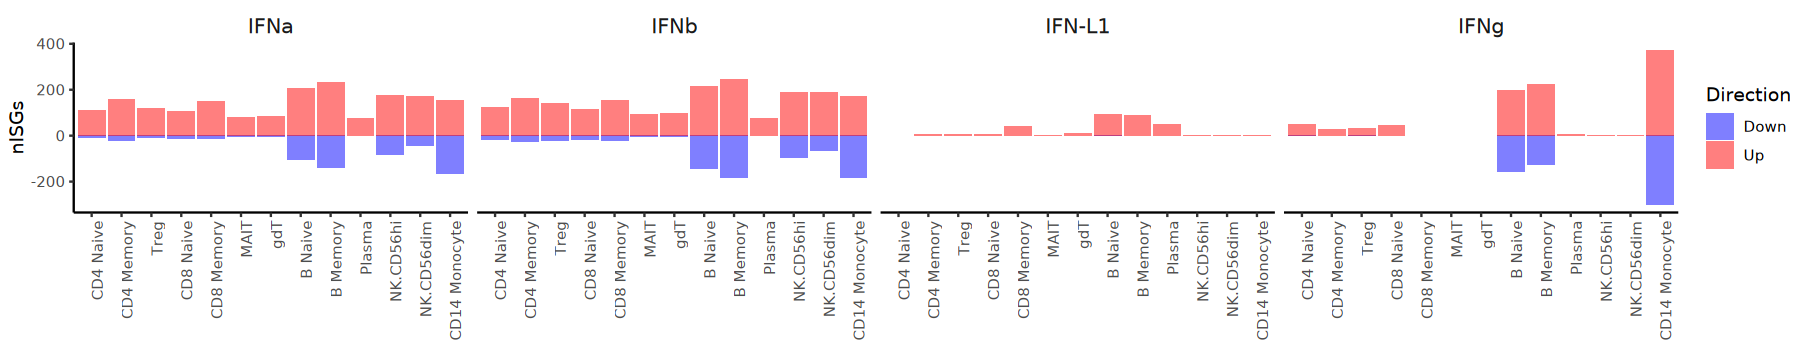

In [39]:
fig.size(3,15)
#pdf(file.path(fig_dir, "Fig1", glue("nISGs_Subtypes_Barplot.pdf")), height = 1.8, width = 7)
ggplot(l2_summary, aes(x=celltype, y=nDEGs, fill=Direction)) +
  geom_bar(stat="identity", alpha = 0.5) + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1), strip.text = element_text(size = 12)) + 
    labs(x = "", y = "nISGs") + 
    scale_fill_manual(values=c('Blue', 'Red')) + 
    facet_wrap(~stim, ncol = 4) + theme(strip.background = element_blank()) 
dev.off()